# Разработка A/B-тестирования и анализ результатов

Вы работаете продуктовым аналитиком в компании, которая разрабатывает развлекательное приложение с функцией «бесконечной» ленты, как, например, в приложениях с короткими видео. В вашем приложении существует две модели монетизации: первая — ежемесячная платная подписка, которая позволяет пользователям смотреть ленту без рекламы, вторая — демонстрация рекламы для пользователей, которые ещё не оформили подписку.

Команда разработчиков рекомендательных систем создала новый алгоритм рекомендаций, который, по их мнению, будет показывать более интересный контент для каждого пользователя. Вас, как аналитика, просят помочь рассчитать параметры A/B-теста, который позволит проверить эту гипотезу, и проанализировать его результаты.

## Описание данных

Вы будете работать с тремя таблицами:

- `sessions_project_history.csv` — таблица с историческими данными по сессиям пользователей на период с 2025-08-15 по 2025-09-23. Путь к файлу: `/datasets/sessions_project_history.csv`.

- `sessions_project_test_part.csv` — таблица с данными за первый день проведения A/B-теста, то есть за 2025-10-14. Путь к файлу: `/datasets/sessions_project_test_part.csv`.

- `sessions_project_test.csv` — таблица с данными за весь период проведения A/B-теста, то есть с 2025-10-14 по 2025-11-02. Путь к файлу: `/datasets/sessions_project_test.csv`.

У этих таблиц почти совпадает структура и содержание колонок, различаются лишь периоды наблюдения.

Поля таблиц `sessions_project_history.csv`, `sessions_project_test.csv`, `sessions_project_test_part.csv`:

- `user_id` — идентификатор пользователя;

- `session_id` — идентификатор сессии в приложении;

- `session_date` — дата сессии;

- `session_start_ts` — дата и время начала сессии;

- `install_date` — дата установки приложения;

- `session_number` — порядковый номер сессии для конкретного пользователя;

- `registration_flag` — является ли пользователь зарегистрированным;

- `page_counter` — количество просмотренных страниц во время сессии;

- `region` — регион пользователя;

- `device` — тип устройства пользователя;

- `test_group` — тестовая группа (в таблице с историческими данными этого столбца нет).


## Что нужно сделать
Ваши задачи: рассчитать параметры теста, оценить корректность его проведения и проанализировать результаты эксперимента.

### 1. Работа с историческими данными (EDA)

#### 1.1. Загрузка исторических данных
На первом этапе поработайте с историческими данными приложения:

- Импортируйте библиотеку pandas.

- Считайте и сохраните в датафрейм `sessions_history` CSV-файл с историческими данными о сессиях пользователей `sessions_project_history.csv`.

Выведите на экран первые пять строк полученного датафрейма.

In [1]:
import pandas as pd

In [2]:
sessions_history = pd.read_csv('https://code.s3.yandex.net/datasets/sessions_project_history.csv')

In [3]:
sessions_history.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android


#### 1.2. Знакомство с данными
- Для каждого уникального пользователя `user_id` рассчитайте количество уникальных сессий `session_id`.

- Выведите на экран все данные из таблицы `sessions_history` для одного пользователя с наибольшим количеством сессий. Если таких пользователей несколько, выберите любого из них.

- Изучите таблицу для одного пользователя, чтобы лучше понять логику формирования каждого столбца данных.

In [4]:
sessions_user_id = sessions_history.groupby('user_id')['session_id'].nunique()
max_user = sessions_user_id.index[0]
max_user_df = sessions_history[sessions_history['user_id'] == max_user]
max_user_df.head(len(max_user_df))

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
19324,00005FB6A13A6FBE,0412A88ADCBDFA14,2025-08-29,2025-08-29 18:02:32,2025-08-29,1,0,3,CIS,iPhone
283278,00005FB6A13A6FBE,AE8C612624715CDB,2025-09-02,2025-09-02 23:29:50,2025-08-29,2,0,3,CIS,iPhone


In [5]:
sess_user_id = sessions_history.groupby('user_id')['session_id'].value_counts().idxmax()
user_id, session_id = sess_user_id
user_data = sessions_history[sessions_history['user_id'] == user_id]
user_data

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
19324,00005FB6A13A6FBE,0412A88ADCBDFA14,2025-08-29,2025-08-29 18:02:32,2025-08-29,1,0,3,CIS,iPhone
283278,00005FB6A13A6FBE,AE8C612624715CDB,2025-09-02,2025-09-02 23:29:50,2025-08-29,2,0,3,CIS,iPhone


#### 1.3. Анализ числа регистраций
Одна из важнейших метрик продукта — число зарегистрированных пользователей. Используя исторические данные, визуализируйте, как менялось число регистраций в приложении за время его существования. Пользователь считается зарегистрированным только в день совершения регистрации. Таким образом, вам необходимо проанализировать количество зарегистрированных активных пользователей за каждый день без накопления (аналог DAU, но для регистраций пользователей).

- Агрегируйте исторические данные и рассчитайте число уникальных пользователей и число зарегистрированных пользователей для каждого дня наблюдения. Для простоты считайте, что у пользователя в течение дня бывает одна сессия максимум и статус регистрации в течение одного дня не может измениться.

- Постройте линейные графики общего числа пользователей и общего числа зарегистрированных пользователей по дням. Отобразите их на одном графике.

- Постройте отдельный линейный график доли зарегистрированных пользователей от всех пользователей по дням.

- На обоих графиках должны быть заголовок, подписанные оси X и Y, сетка и легенда.

In [6]:
all_dist_users = sessions_history.groupby('session_date')['user_id'].nunique()
reg_users = sessions_history[sessions_history['registration_flag'] == 1]
all_reg_users = reg_users.groupby('session_date')['user_id'].nunique()

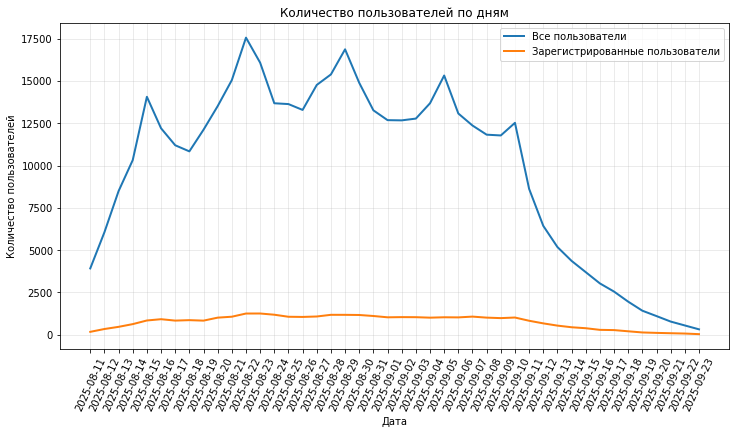

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(all_dist_users.index,
         all_dist_users.values,
         linewidth=2,
         label = 'Все пользователи')

plt.plot(all_reg_users.index,
         all_reg_users.values,
         linewidth=2,
         label = 'Зарегистрированные пользователи'
)
plt.title('Количество пользователей по дням')
plt.xlabel('Дата')
plt.ylabel('Количество пользователей')
plt.grid(True, alpha = 0.3)
plt.legend()
plt.xticks(rotation=65)

plt.show()

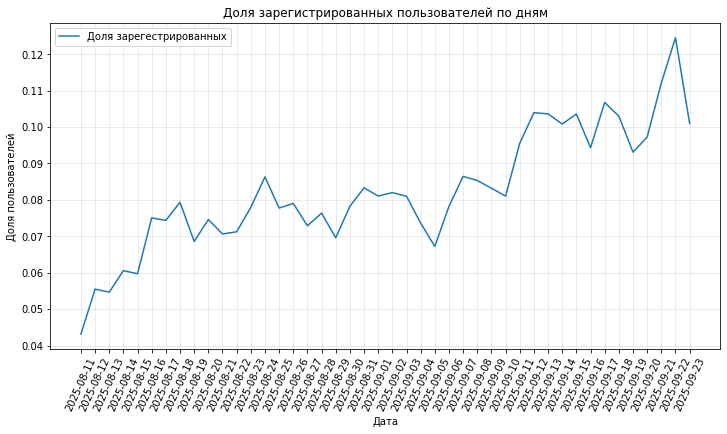

In [8]:
plt.figure(figsize=(12, 6))

shape = all_reg_users / all_dist_users

plt.plot(shape.index,
         shape.values,
         label = 'Доля зарегестрированных'
        )

plt.title('Доля зарегистрированных пользователей по дням')
plt.xlabel('Дата')
plt.ylabel('Доля пользователей')
plt.grid(True, alpha = 0.3)
plt.legend()
plt.xticks(rotation=65)

plt.show()

**Число пользователей со временем падает, но качество трафика растёт — доля зарегистрированных увеличилась с 4% до 10–12%**

#### 1.4. Анализ числа просмотренных страниц
Другая важная метрика продукта — число просмотренных страниц в приложении. Чем больше страниц просмотрено, тем сильнее пользователь увлечён контентом, а значит, выше шансы, что он зарегистрируется и оплатит подписку.

В рамках задания проанализируйте число просмотренных страниц во время первых сессий пользователей. Найдите количество первых сессий для каждого значения количества просмотренных страниц. Например: одну страницу просмотрели в 8978 первых сессиях, две страницы — в 32 494 первых сессиях и так далее.

- Постройте столбчатую диаграмму, где по оси X будет число просмотренных страниц, по оси Y — количество сессий.

- На диаграмме должны быть заголовок, подписанные оси X и Y.

In [9]:
first_session_df = sessions_history[sessions_history['session_number'] == 1]
f_s_df = first_session_df['page_counter'].value_counts()
f_s_df

3    50939
4    32739
2    32494
1     8978
5     8075
6      777
7       37
Name: page_counter, dtype: int64

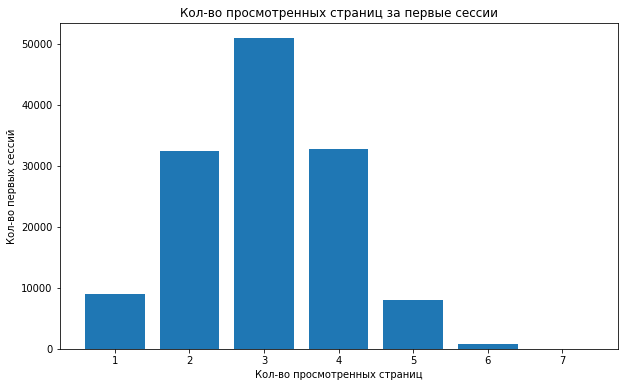

In [10]:
plt.figure(figsize=(10, 6))

plt.bar(f_s_df.index,
        f_s_df.values,
       )
plt.title('Кол-во просмотренных страниц за первые сессии')
plt.xlabel('Кол-во просмотренных страниц')
plt.ylabel('Кол-во первых сессий')
plt.show()

**Наибольшее количество первых сессий (50 939) приходится на 3 просмотренные страницы. Пик активности приходится на 3–4 страницы, после чего наблюдается резкий спад: большинство пользователей покидают приложение на этом этапе, так и не перейдя к глубокому изучению контента.**

#### 1.5. Доля пользователей, просмотревших более четырёх страниц
Продуктовая команда продукта считает, что первые сессии, в рамках которых пользователь просмотрел 4 и более страниц, говорят об удовлетворённости контентом и алгоритмами рекомендаций. Этот показатель является важной прокси-метрикой для продукта.

- В датафрейме `sessions_history` создайте дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если было просмотрено меньше.

- Постройте график со средним значением доли успешных первых сессий от всех первых сессий пользователей. Данные нужно визуализировать по дням за весь период наблюдения.

In [11]:
sessions_history['good_session'] = (sessions_history['page_counter'] >= 4).astype(int)

In [12]:
all_shape = sessions_history[sessions_history['session_number'] == 1].groupby('session_date')['good_session'].mean()

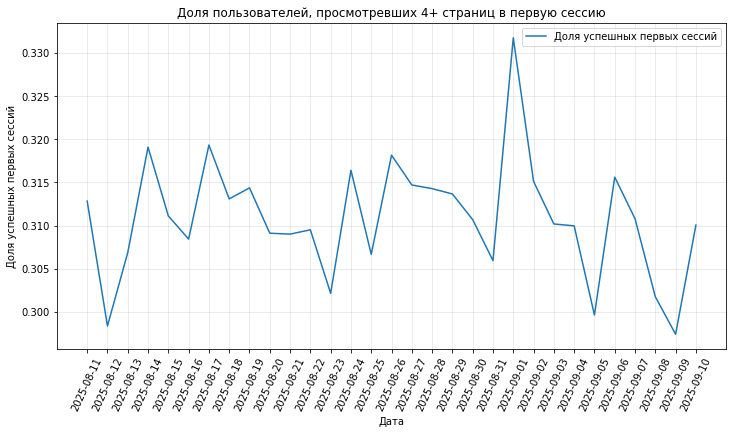

In [13]:
plt.figure(figsize=(12, 6))

plt.plot(all_shape.index,
         all_shape.values,
         label = 'Доля успешных первых сессий'
        )

plt.title('Доля пользователей, просмотревших 4+ страниц в первую сессию')
plt.xlabel('Дата')
plt.ylabel('Доля успешных первых сессий')
plt.grid(True, alpha = 0.3)
plt.legend()
plt.xticks(rotation=65)

plt.show()

**Доля пользователей, просмотревших 4+ страниц в первую сессию, на протяжении всего периода наблюдения колеблется в диапазоне от 29% до 33%. В среднем около 31% первых сессий можно считать «успешными». Заметен локальный пик 2025-09-01, когда показатель превысил 33%, однако в целом метрика остаётся относительно стабильной без явного тренда на значительный рост или падение.**

### 2. Подготовка к тесту
При планировании теста необходимо проделать несколько важных шагов:

- Определиться с целевой метрикой.

- Рассчитать необходимый размер выборки.

- Исходя из текущих значений трафика рассчитать необходимую длительность проведения теста.

#### 2.1. Расчёт размера выборки
В рамках курса вы уже рассчитывали размеры выборки и  использовали для этого онлайн-калькулятор. В этом задании предлагаем воспользоваться готовым кодом и рассчитать необходимое для вашего эксперимента количество пользователей.

Для этого установите в коде ниже следующие параметры:

- Уровень значимости — 0.05.

- Вероятность ошибки второго рода — 0.2.

- Мощность теста.

- Минимальный детектируемый эффект, или MDE, — 3%. Обратите внимание, что здесь нужно указать десятичную дробь, а не процент.

При расчёте размера выборки используйте метод `solve_power()` из класса `power.NormalIndPower` модуля `statsmodels.stats`.

Запустите ячейку и изучите полученное значение.

In [14]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

# Задайте параметры:
alpha = 0.05 # Уровень значимости
beta = 0.2  # Ошибка второго рода, часто 1 - мощность
power = 0.8  # Мощность теста
p = 0.3 # Базовый уровень доли
mde = p * 0.03  # Минимальный детектируемый эффект
effect_size = proportion_effectsize(p, p + mde)

# Инициализируем класс NormalIndPower
power_analysis = NormalIndPower()

# Расчёт размера выборки
sample_size = power_analysis.solve_power(
    effect_size = effect_size,
    power = power,
    alpha = alpha,
    ratio = 1 # Равномерное распределение выборок
)

print(f"Необходимый размер выборки для каждой группы: {int(sample_size)}")

Необходимый размер выборки для каждой группы: 41040


#### 2.2. Расчёт длительности A/B-теста

Используйте данные о количестве пользователей в каждой выборке и среднем количестве пользователей приложения. Рассчитайте длительность теста, разделив одно на другое.

- Рассчитайте среднее количество уникальных пользователей приложения в день.

- Определите длительность теста исходя из рассчитанного значения размера выборок и среднего дневного трафика приложения. Количество дней округлите в большую сторону.

In [15]:
from math import ceil

# Среднее количество пользователей приложения в день по историческим данным
avg_daily_users = sessions_history.groupby('session_date')['user_id'].nunique().mean()

# Рассчитываем длительность теста в днях как отношение размера выборки к среднему числу пользователей
test_duration = ceil((sample_size * 2) / avg_daily_users)

print(f"Рассчитанная длительность A/B-теста при текущем уровне трафика в {avg_daily_users} пользователей в день составит {test_duration} дней")

Рассчитанная длительность A/B-теста при текущем уровне трафика в 9907.363636363636 пользователей в день составит 9 дней


### 3. Мониторинг А/В-теста

#### 3.1. Проверка распределения пользователей

A/B-тест успешно запущен, и уже доступны данные за первые три дня. На этом этапе нужно убедиться, что всё идёт хорошо: пользователи разделены правильным образом, а интересующие вас метрики корректно считаются.

- Считайте и сохраните в датафрейм `sessions_test_part` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test_part.csv`.

- Рассчитайте количество уникальных пользователей в каждой из экспериментальных групп для одного дня наблюдения.

- Рассчитайте и выведите на экран процентную разницу в количестве пользователей в группах A и B. Постройте любую удобную визуализацию, на которой будет видно возможное различие двух групп.

Для расчёта процентной разницы воспользуйтесь формулой:
$$P = 100 \cdot  \frac{|A − B|}{A}$$

In [16]:
sessions_test_part = pd.read_csv('https://code.s3.yandex.net/datasets/sessions_project_test_part.csv')
sessions_test_part.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group
0,3404844B53442747,B4901323BD537E45,2025-10-14,2025-10-14 19:28:49,2025-10-14,1,0,3,CIS,Android,B
1,3A2BF4D364E62D89,216FC619308F8788,2025-10-14,2025-10-14 21:11:04,2025-10-14,1,0,3,MENA,iPhone,A
2,79CDAE11E32B1597,EDFCE4AC1A504074,2025-10-14,2025-10-14 21:44:03,2025-10-14,1,0,3,CIS,iPhone,A
3,D6AF8D78297A931F,CF0AC0EEDE92C690,2025-10-14,2025-10-14 19:07:55,2025-10-14,1,0,4,CIS,PC,A
4,37E0CE723AE568E0,2E6ED45E8C86C4E9,2025-10-14,2025-10-14 15:39:44,2025-10-14,1,0,3,CIS,Mac,B


In [17]:
users_per_day = sessions_test_part.groupby('test_group')['user_id'].nunique()
users_per_day

test_group
A    1477
B    1466
Name: user_id, dtype: int64

In [18]:
A = 1477
B = 1466
P = 100 * ((A - B) / A)
round(P, 2)

0.74

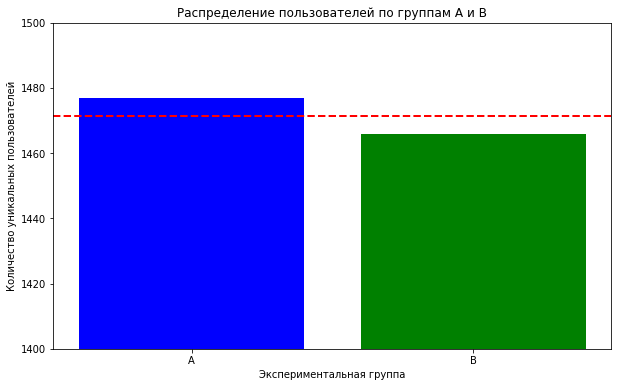

In [19]:
plt.figure(figsize=(10, 6))

plt.bar(users_per_day.index,
        users_per_day.values,
        color=['blue', 'green']
       )

plt.axhline(y=users_per_day.mean(), 
            color='red', 
            linestyle='--', 
            linewidth=2)

plt.ylim(1400, 1500)
plt.title('Распределение пользователей по группам A и B')
plt.xlabel('Экспериментальная группа')
plt.ylabel('Количество уникальных пользователей')
plt.show()

#### 3.2. Проверка пересечений пользователей
Помимо проверки равенства количества пользователей в группах, полезно убедиться в том, что группы независимы. Для этого нужно убедиться, что никто из пользователей случайно не попал в обе группы одновременно.

- Рассчитайте количество пользователей, которые встречаются одновременно в группах A и B, или убедитесь, что таких нет.

In [20]:
users_A = sessions_test_part[sessions_test_part['test_group'] == 'A']['user_id']
users_B = sessions_test_part[sessions_test_part['test_group'] == 'B']['user_id']
intersection = list(set(users_A) & set(users_B))
intersection

[]

#### 3.3. Равномерность разделения пользователей по устройствам
Полезно также убедиться в том, что пользователи равномерно распределены по всем доступным категориальным переменным — типам устройств и регионам.

Постройте две диаграммы:

- доля каждого типа устройства для пользователей из группы A,

- доля каждого типа устройства для пользователей из группы B.

Постарайтесь добавить на диаграммы все необходимые подписи, пояснения и заголовки, которые позволят сделать вывод о том, совпадает ли распределение устройств в группах A и B.


In [21]:
df_A = sessions_test_part[sessions_test_part['test_group'] == 'A']
df_B = sessions_test_part[sessions_test_part['test_group'] == 'B']
df_A_unique = df_A.drop_duplicates(subset='user_id')
df_B_unique = df_B.drop_duplicates(subset='user_id')

In [22]:
A_group = round(df_A_unique['device'].value_counts() / df_A_unique['device'].value_counts().sum() * 100, 2)

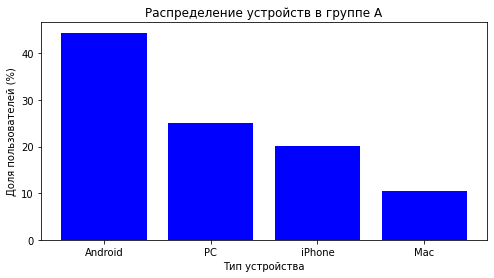

In [23]:
plt.figure(figsize=(8, 4))

plt.bar(A_group.index,
        A_group.values,
        color = 'blue'
       )

plt.title('Распределение устройств в группе A')
plt.xlabel('Тип устройства')
plt.ylabel('Доля пользователей (%)')
plt.show()

In [24]:
B_group = round(df_B_unique['device'].value_counts() / df_B_unique['device'].value_counts().sum() * 100, 2)

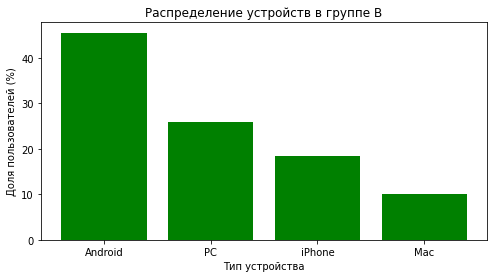

In [25]:
plt.figure(figsize=(8, 4))

plt.bar(B_group.index,
        B_group.values,
        color = 'green'
       )


plt.title('Распределение устройств в группе B')
plt.xlabel('Тип устройства')
plt.ylabel('Доля пользователей (%)')
plt.show()

#### 3.4. Равномерность распределения пользователей по регионам
Теперь убедитесь, что пользователи равномерно распределены по регионам.

Постройте две диаграммы:

- доля каждого региона для пользователей из группы A,

- доля каждого региона для пользователей из группы B.

Постарайтесь добавить на диаграммы все необходимые подписи, пояснения и заголовки, которые позволят сделать вывод о том, совпадает ли распределение регионов в группах A и B. Постарайтесь использовать другой тип диаграммы, не тот, что в прошлом задании.

In [26]:
reg_A = round(df_A_unique.groupby('region')['user_id'].nunique() / df_A_unique.groupby('region')['user_id'].nunique().sum() * 100, 2).sort_values(ascending=False)

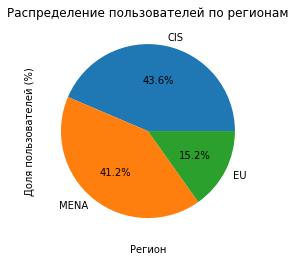

In [27]:
plt.figure(figsize=(8, 4))

plt.pie(reg_A.values, 
            labels=reg_A.index, 
            autopct='%1.1f%%')

plt.title('Распределение пользователей по регионам')
plt.xlabel('Регион')
plt.ylabel('Доля пользователей (%)')
plt.show()

In [28]:
reg_B = round(df_B_unique.groupby('region')['user_id'].nunique() / df_B_unique.groupby('region')['user_id'].nunique().sum() * 100, 2).sort_values(ascending=False)

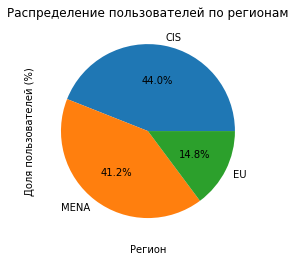

In [29]:
plt.figure(figsize=(8, 4))

plt.pie(reg_B.values, 
            labels=reg_B.index, 
            autopct='%1.1f%%')

plt.title('Распределение пользователей по регионам')
plt.xlabel('Регион')
plt.ylabel('Доля пользователей (%)')
plt.show()

#### 3.5. Вывод после проверки A/B-теста

На основе проведённого анализа A/B-теста сформулируйте и запишите свои выводы. В выводе обязательно укажите:

- Было ли обнаружено различие в количестве пользователей в двух группах.

- Являются ли выборки независимыми. Было ли обнаружено пересечение пользователей из тестовой и контрольной групп.

- Сохраняется ли равномерное распределение пользователей тестовой и контрольной групп по категориальным переменным: устройствам и регионам.

Сделайте заключение: корректно ли проходит A/B-тест, или наблюдаются какие-либо нарушения.

1. Различие в количестве пользователей в группах A и B 

Количество уникальных пользователей в группе A составило 1477, в группе B — 1466. Процентная разница между группами равна 0.74%. Это незначительное отклонение, которое говорит о корректном разделении трафика между группами.

2. Независимость выборок

При проверке пересечений пользователей между группами A и B было обнаружено, что ни один пользователь не встречается одновременно в обеих группах. Это означает, что выборки независимы и соответствуют корректноым требованиям.

3. Равномерность распределения по категориальным переменным

По устройствам: доли типов устройств в группах A и B примерно одинаковы, наибольшая разница наблюдается по Android - 5%, по остальным устройствам разница не превышает 3%, это указывает о равномерном распределении

По регионам: доли регионов в группах A и B также близки, наибольшая разница наблюдается по региону MENA - 6%, разница по другим регионам не превышает 4%.

4. Общее заключение

На основе проведённого анализа можно сделать следующие выводы:

Количество пользователей в группах A и B примерно одинаковое, выборки независимы — пересечений пользователей между группами не обнаружено, распределение по устройствам и регионам в целом равномерное, наблюдаемые различия незначительны.

### 4. Проверка результатов A/B-теста

A/B-тест завершён, и у вас есть результаты за все дни проведения эксперимента. Необходимо убедиться в корректности теста и верно интерпретировать результаты.

#### 4.1. Получение результатов теста и подсчёт основной метрики

- Считайте и сохраните в датафрейм `sessions_test` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test.csv`.

- В датафрейме `sessions_test` создайте дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если просмотрено меньше.

In [30]:
sessions_test = pd.read_csv('https://code.s3.yandex.net/datasets/sessions_project_test.csv')
sessions_test.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group
0,6DAE3B3654DA738E,C69249E26E58F6E2,2025-10-26,2025-10-26 18:15:05,2025-10-16,3,0,3,MENA,Android,A
1,0A3FE5D1DD59110A,66D66D7C9F5181B7,2025-10-21,2025-10-21 17:04:53,2025-10-15,2,1,2,CIS,Android,B
2,2041F1D7AA740B88,50DE51D42215E74C,2025-10-23,2025-10-23 17:39:29,2025-10-19,3,0,2,MENA,Android,A
3,43D7585009168086,5763C0C353C22263,2025-10-24,2025-10-24 15:01:57,2025-10-18,4,0,1,CIS,iPhone,B
4,15AD68B14D62D88C,B1AD09F93C1053BC,2025-10-17,2025-10-17 17:34:39,2025-10-17,1,0,2,MENA,Android,B


In [31]:
sessions_test['good_session'] = (sessions_test['page_counter'] >= 4).astype(int)

#### 4.2 Формулировка нулевой и альтернативной гипотез. Определение целевой, прокси- и барьерных метрик


Перед тем как проводить А/B-тест, необходимо сформулировать нулевую и альтернативную гипотезы. Напомним изначальное условие: команда разработчиков рекомендательных систем создала новый алгоритм, который, по их мнению, будет показывать более интересный контент для каждого пользователя.

Подумайте, о какой метрике идёт речь и как она будет учтена в формулировке гипотез. Сформулируйте нулевую и альтернативную гипотезы.

Не забывайте, что до проведения эксперимента важно выделять и отслеживать изменение прокси- и барьерных метрик. В имеющихся у вас данных о проведении эксперимента этих метрик нет. Подумайте, какие показатели вы бы выбрали в качестве прокси- и барьерных метрик, если бы проводили этот эксперимент самостоятельно.

**Гипотезы**

- **Нулевая: Доля успешных первых сессий (просмотр 4+ страниц) в группе с новым алгоритмом рекомендаций не отличается от контрольной группы.**
- **Альтернативная: Доля успешных первых сессий (просмотр 4+ страниц) в группе с новым алгоритмом рекомендаций выше, чем в контрольной группе.**


Целевая метрика: доля успешных первых сессий (good_session = просмотр 4+ страниц за первую сессию) - отражает вовлечённость и интерес пользователя к контенту.

Прокси-метрика: среднее количество просмотренных страниц за сессию (page_counter) - индикатор активности.

Барьерная метрика: доля зарегистрированных пользователей (registration_flag) - новый алгоритм не должен снижать конверсию в регистрацию.

#### 4.3. Сравнение доли успешных первых сессий

Перейдем к анализу ключевой метрики — доле успешных первых сессий.

Используйте созданный на первом шаге задания столбец `good_session` и рассчитайте долю успешных первых сессий для выборок A и B, а также разницу в этом показателе. Полученный вывод отобразите на экране.

In [32]:
success_fs_df = sessions_test[sessions_test['session_number'] == 1]
success_df_A = success_fs_df[success_fs_df['test_group'] == 'A']
success_df_B = success_fs_df[success_fs_df['test_group'] == 'B']

success_A = success_df_A['good_session'].mean()
print("Доля успешных первых сессий в группе А:", round(success_A, 2))
success_B = success_df_B['good_session'].mean()
print("Доля успешных первых сессий в группе B:", round(success_B, 2))
print("Разница между группами B и A:", success_B - success_A)

Доля успешных первых сессий в группе А: 0.32
Доля успешных первых сессий в группе B: 0.31
Разница между группами B и A: -0.0010504523811919464


#### 4.4. Насколько статистически значимо изменение ключевой метрики

На предыдущем шаге вы убедились, что доли успешных первых сессий в тестовой и контрольной выборках близки, но делать выводы только на основе этого значения будет некорректно. Для принятия решения всегда необходимо отвечать на вопрос: является ли это изменение статистически значимым.

- Используя статистический тест, рассчитайте, является ли изменение в метрике доли успешных первых сессий статистически значимым.

- Выведите на экран полученное значение p-value и свои выводы о статистической значимости. Напомним, что уровень значимости в эксперименте был выбран на уровне 0.05.

In [33]:
success_count_A = success_df_A['good_session'].sum()
success_count_B = success_df_B['good_session'].sum()

In [34]:
first_session_users_A = success_df_A['user_id'].count()
first_session_users_B = success_df_B['user_id'].count()

In [35]:
from statsmodels.stats.proportion import proportions_ztest

alpha = 0.05

stat_ztest, p_value_ztest = proportions_ztest(
    [success_count_B, success_count_A],
    [first_session_users_B, first_session_users_A],
    alternative= 'larger'
)
print(f"p-value = {p_value_ztest}")

if p_value_ztest > alpha:
    print(f"Не можем отвергнуть нулевую гипотезу, новые алгоритмы не добились успеха")
else:
    print(f"Принимаем альтернативную гипотезу, новый алгоритм лучше")

p-value = 0.5783523649187868
Не можем отвергнуть нулевую гипотезу, новые алгоритмы не добились успеха


#### 4.5. Вывод по результатам A/B-эксперимента

На основе проведённого анализа результатов теста сформулируйте и запишите свои выводы для команды разработки приложения. В выводе обязательно укажите:

- Характеристики проведённого эксперимента, количество задействованных пользователей и длительность эксперимента.

- Повлияло ли внедрение нового алгоритма рекомендаций на рост ключевой метрики и как.

- Каким получилось значение p-value для оценки статистической значимости выявленного эффекта.

- Стоит ли внедрять нововведение в приложение.

Характеристики эксперимента:

- Целевая метрика: доля успешных первых сессий (просмотр 4+ страниц за первую сессию)

- Количество пользователей: группа A — 1477, группа B — 1466 (за первый день)

- Длительность эксперимента: 9 день

Результат влияния нового алгоритма:
- Новый алгоритм рекомендаций не привёл к росту целевой метрики. Доля успешных первых сессий в группе B (31%) оказалась даже немного ниже, чем в группе A (32%).

Статистическая значимость:

- p-value = 0.57

- p-value > 0.05, это указывает на то, что разница не является статистически значимой

Решение:
- Внедрять нововведение не стоит. Новый алгоритм не показал значимого улучшения, поэтому рекомендуется оставить текущий алгоритм рекомендаций.